<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/LAB04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 04

## Penalized regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso

# Truth model
N = 50 # Number of predictors
M = 6 # NUmber of nonzero predictors
model_var = 3
noise_var = 20

# Betas
np.random.seed(42)
nonzero_indexes = np.random.choice(np.arange(0, N), size=M, replace=False)
betas = np.zeros(50)
for index in nonzero_indexes:
    betas[index] = np.random.uniform(-20, 20)

# Test data
n_test_samples = 5000
X_test = np.random.normal(0, model_var, (n_test_samples, N))
Noise_test = np.random.normal(0, noise_var, n_test_samples)
Y_test_true = X_test @ betas
Y_test = Y_test_true + Noise_test

# Bias-Variance Decomposition function for Ridge and Lasso regression
def bias_variance_decomposition(alpha):
    ridge_model = Ridge(alpha=alpha)
    lasso_model = Lasso(alpha=alpha)

    n_simulations = 100
    ridge_predictions = np.zeros((n_simulations, n_test_samples))
    lasso_predictions = np.zeros((n_simulations, n_test_samples))

    for i in range(n_simulations):
        n_train_samples = 50
        X_train = np.random.normal(0, model_var, (n_train_samples, N))
        Noise_train = np.random.normal(0, noise_var, n_train_samples)
        Y_train = X_train @ betas + Noise_train

        ridge_model.fit(X_train, Y_train)
        lasso_model.fit(X_train, Y_train)

        ridge_predictions[i, :] = ridge_model.predict(X_test)
        lasso_predictions[i, :] = lasso_model.predict(X_test)

    ridge_expected_predictions = np.mean(ridge_predictions, axis=0)
    lasso_expected_predictions = np.mean(lasso_predictions, axis=0)

    ridge_bias_sq_per_point = (ridge_expected_predictions - Y_test_true) ** 2
    lasso_bias_sq_per_point = (lasso_expected_predictions - Y_test_true) ** 2
    ridge_variance_per_point = np.var(ridge_predictions, axis=0)
    lasso_variance_per_point = np.var(lasso_predictions, axis=0)

    ridge_mse_per_point = np.mean((ridge_predictions - Y_test) ** 2, axis=0)
    lasso_mse_per_point = np.mean((lasso_predictions - Y_test) ** 2, axis=0)

    ridge_bias_squared = np.mean(ridge_bias_sq_per_point)
    ridge_variance = np.mean(ridge_variance_per_point)
    ridge_mse = np.mean(ridge_mse_per_point)

    lasso_bias_squared = np.mean(lasso_bias_sq_per_point)
    lasso_variance = np.mean(lasso_variance_per_point)
    lasso_mse = np.mean(lasso_mse_per_point)

    return ridge_bias_squared, ridge_variance, ridge_mse, lasso_bias_squared, lasso_variance, lasso_mse

alphas = np.logspace(-1, 3, 100)
results = []
for alpha in alphas:
    results.append(bias_variance_decomposition(alpha))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.933e+02, tolerance: 4.168e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.510e+01, tolerance: 4.015e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.601e+01, tolerance: 2.109e

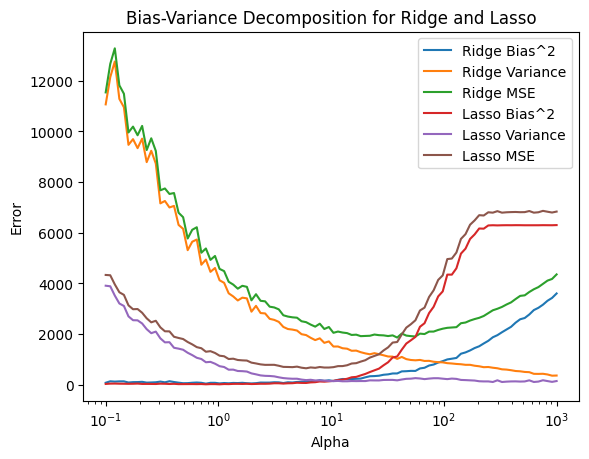

In [2]:
# 6. Plotting results
plt.plot(alphas, [result[0] for result in results], label='Ridge Bias^2')
plt.plot(alphas, [result[1] for result in results], label='Ridge Variance')
plt.plot(alphas, [result[2] for result in results], label='Ridge MSE')
plt.plot(alphas, [result[3] for result in results], label='Lasso Bias^2')
plt.plot(alphas, [result[4] for result in results], label='Lasso Variance')
plt.plot(alphas, [result[5] for result in results], label='Lasso MSE')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Error')
plt.title('Bias-Variance Decomposition for Ridge and Lasso')
plt.legend()
plt.show()

## Questions

### How does varying the regularization parameter in Ridge and Lasso regression impact the trade-off between bias and variance?
$\text{Bias}^2$ is increasing function of penalty scale $\alpha$ and variance is decreasing function of it.
$\text{MSE}$ looks almost like convex function of $\alpha$.

### Explain MSE decomposition into bias and variance and irreducible error.
$$ \text{MSE} = \text{Bias}^2 + \text{Var} + \text{Irreducible error} $$

### Does the regularization lead to an optimal trade-off point where MSE is minimized? Explain why this point exists.
Yes. It is connected to Hoerl-Kennard theorem.
One can show, that variance is convex and decreasing to 0 function of $\alpha$
and $\text{Bias}^2$ is convex and increasing function of $\alpha$ up to its maximum.
So the sweat spot of MSE exists.

### Analyze how Ridge and Lasso differ in terms of their bias-variance trade-offs.
Lasso sweat spot MSE is much lower than sweat spot for Ridge,
because Lasso puts many betas to zero. Lasso variance is lower than Ridge variance.
Opposite is for $\text{Bias}^2$. For some $\alpha$ $\text{Bias}^2$ for Lasso reach its maximum.
Best $\alpha$ for Lasso is about ten times smaller than for Ridge.

### Discuss situations where one method may outperform the other, considering factors like feature sparsity and multicollinearity.

1. Feature Sparsity (Winner: Lasso)

The Scenario: You have a dataset with a massive number of features, but you suspect that only a small handful of them actually influence the target variable. The rest are just noise. (For example, predicting a disease based on 10,000 gene expressions, where only 5 specific genes actually matter). Why Lasso wins: Lasso applies an absolute value penalty: $\lambda \sum_{i=1}^p |\beta_i|$. Because of those sharp corners in its geometric shape, Lasso will drive the coefficients of useless features to exactly zero. It performs automatic feature selection, tossing out the garbage and leaving you with a simple, highly interpretable model containing only the most important variables. Why Ridge fails: Ridge applies a squared penalty: $\lambda \sum_{i=1}^p \beta_i^2$. This penalty is very harsh on large coefficients but becomes incredibly weak as coefficients get close to zero. Therefore, Ridge will shrink the noise features to be very small (e.g., 0.001), but it will almost never set them to exactly zero. You are left with a dense, complex model that still drags around thousands of irrelevant features.

2. Multicollinearity (Winner: Ridge)

The Scenario: Your features are highly correlated with one another. For example, if you are predicting house prices, features like "square footage," "number of bedrooms," and "number of bathrooms" all rise and fall together. Why Ridge wins: Ridge handles correlated features beautifully. Because squaring a large number creates a massive penalty, Ridge hates putting all its weight on one feature. Instead, it prefers to shrink the coefficients together and distribute the weight smoothly across the correlated group. This keeps the model highly stable, reduces variance, and generally yields a better overall Mean Squared Error (MSE).Why Lasso struggles: Lasso is notoriously erratic when faced with multicollinearity. If it sees three highly correlated features, it will essentially pick one at random, assign it a large coefficient, and violently zero out the other two. If your data changes even slightly (e.g., you drop a few rows), Lasso might suddenly pick a different feature from that group. This makes the model highly unstable and hurts its predictive accuracy.